
# Partie I — MLP et PyTorch
## Projet Deep Learning EMSI 2025–2026

### Objectif
Dans cette partie, nous allons :
- préparer un dataset tabulaire réel,
- construire un MLP avec PyTorch,
- entraîner et évaluer le modèle,
- comparer différentes techniques d’initialisation,
- sauvegarder et recharger le modèle.


In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)



# Vérification du CPU / GPU
PyTorch peut utiliser le GPU si disponible.


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device utilisé :", device)


Device utilisé : cpu



# Chargement du Dataset
Nous utilisons le dataset Breast Cancer Wisconsin.


In [ ]:

data = load_breast_cancer()

X = data.data
y = data.target

print("Shape X :", X.shape)
print("Shape y :", y.shape)


Shape X : (569, 30)
Shape y : (569,)



# Analyse Rapide des Données


In [ ]:

print(data.feature_names)
print(data.target_names)


['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
['malignant' 'benign']



# Séparation Train / Test
80% entraînement et 20% test.


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)


(455, 30)
(114, 30)



# Normalisation des Données
La normalisation améliore la stabilité de l’apprentissage.


In [ ]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



# Conversion vers des Tensors PyTorch


In [ ]:

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)



# Envoi vers le Device


In [ ]:

X_train = X_train.to(device)
X_test = X_test.to(device)

y_train = y_train.to(device)
y_test = y_test.to(device)



# MLP avec Classe Personnalisée


In [ ]:

class MLP(nn.Module):

    def __init__(self):
        super(MLP, self).__init__()

        self.fc1 = nn.Linear(30, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x



# Création du Modèle


In [ ]:

model = MLP().to(device)

print(model)


MLP(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
  (relu): ReLU()
)



# Inspection des Paramètres


In [ ]:

for name, param in model.named_parameters():
    print(name)
    print(param.shape)
    print("-" * 50)


fc1.weight
torch.Size([64, 30])
--------------------------------------------------
fc1.bias
torch.Size([64])
--------------------------------------------------
fc2.weight
torch.Size([32, 64])
--------------------------------------------------
fc2.bias
torch.Size([32])
--------------------------------------------------
fc3.weight
torch.Size([2, 32])
--------------------------------------------------
fc3.bias
torch.Size([2])
--------------------------------------------------



# Initialisation Xavier


In [ ]:

nn.init.xavier_uniform_(model.fc1.weight)
nn.init.xavier_uniform_(model.fc2.weight)
nn.init.xavier_uniform_(model.fc3.weight)


Parameter containing:
tensor([[-0.3548,  0.1944,  0.1992, -0.2023,  0.1255, -0.1397,  0.1200, -0.3617,
          0.2122, -0.0783, -0.1802, -0.2803, -0.3088, -0.1037, -0.1052,  0.3350,
          0.1700, -0.4049,  0.0346,  0.3527,  0.1466, -0.1912,  0.3912, -0.3023,
         -0.3683,  0.0635, -0.0312, -0.3729,  0.2426, -0.4150,  0.2218,  0.3412],
        [-0.0766, -0.0228,  0.0644,  0.0469,  0.3349,  0.3039,  0.2599,  0.2789,
         -0.1613,  0.2804, -0.1289,  0.2963, -0.0989, -0.1069,  0.3695,  0.3116,
         -0.3505, -0.2971,  0.3412, -0.1809, -0.1113,  0.0445, -0.0438, -0.0149,
          0.2230,  0.2343,  0.3303,  0.3772, -0.2064,  0.4178,  0.2945,  0.0060]],
       requires_grad=True)


# Fonction de Coût et Optimizer


In [ ]:

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)



# Entraînement du Modèle


In [ ]:

num_epochs = 100

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    _, predicted = torch.max(outputs, 1)

    accuracy = (predicted == y_train).float().mean()

    train_losses.append(loss.item())
    train_accuracies.append(accuracy.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {loss.item():.4f} | Accuracy: {accuracy.item():.4f}")


Epoch [10/100] | Loss: 0.4588 | Accuracy: 0.7758
Epoch [20/100] | Loss: 0.2582 | Accuracy: 0.9275
Epoch [30/100] | Loss: 0.1737 | Accuracy: 0.9582
Epoch [40/100] | Loss: 0.1258 | Accuracy: 0.9780
Epoch [50/100] | Loss: 0.0974 | Accuracy: 0.9780
Epoch [60/100] | Loss: 0.0797 | Accuracy: 0.9824
Epoch [70/100] | Loss: 0.0679 | Accuracy: 0.9846
Epoch [80/100] | Loss: 0.0592 | Accuracy: 0.9868
Epoch [90/100] | Loss: 0.0523 | Accuracy: 0.9868
Epoch [100/100] | Loss: 0.0464 | Accuracy: 0.9868



# Courbe de Loss


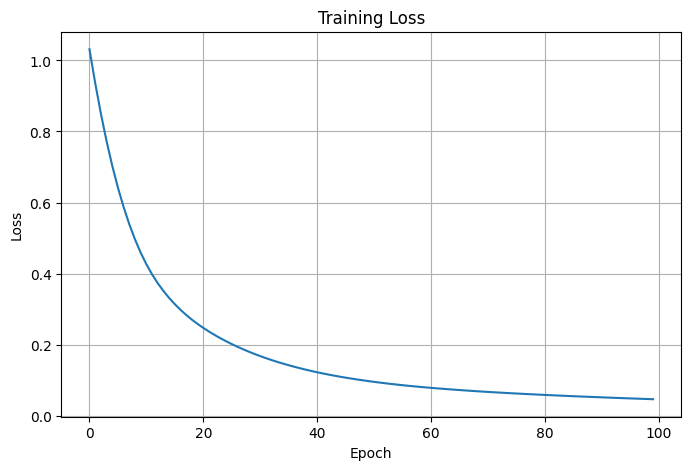

In [ ]:

plt.figure(figsize=(8,5))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()



# Courbe Accuracy


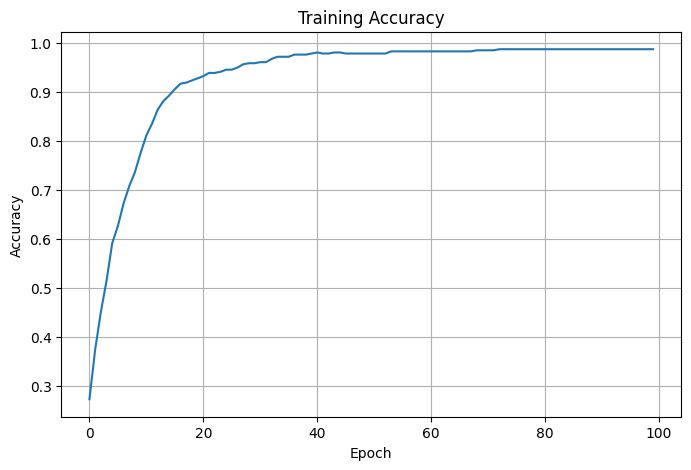

In [ ]:

plt.figure(figsize=(8,5))
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.show()



# Évaluation du Modèle


In [ ]:

model.eval()

with torch.no_grad():

    test_outputs = model(X_test)

    _, predicted = torch.max(test_outputs, 1)


In [ ]:

y_test_cpu = y_test.cpu()
predicted_cpu = predicted.cpu()

acc = accuracy_score(y_test_cpu, predicted_cpu)
precision = precision_score(y_test_cpu, predicted_cpu)
recall = recall_score(y_test_cpu, predicted_cpu)
f1 = f1_score(y_test_cpu, predicted_cpu)

print("Accuracy :", acc)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)


Accuracy : 0.956140350877193
Precision : 0.9855072463768116
Recall : 0.9444444444444444
F1 Score : 0.9645390070921985



# Rapport de Classification


In [ ]:

print(classification_report(y_test_cpu, predicted_cpu))


              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114




# Matrice de Confusion


[[41  1]
 [ 4 68]]


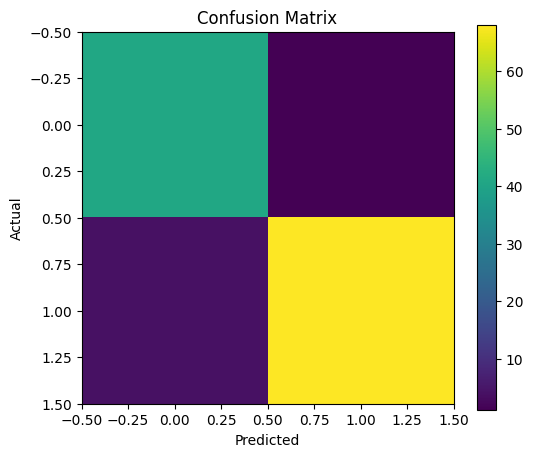

In [ ]:

cm = confusion_matrix(y_test_cpu, predicted_cpu)

print(cm)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



# Sauvegarde du Modèle


In [ ]:

torch.save(model.state_dict(), "best_model.pth")

print("Modèle sauvegardé")


Modèle sauvegardé



# Rechargement du Modèle


In [ ]:

loaded_model = MLP().to(device)

loaded_model.load_state_dict(torch.load("best_model.pth"))

loaded_model.eval()

print("Modèle rechargé avec succès")


Modèle rechargé avec succès


# Conclusion

Cette implémentation montre qu'un perceptron multicouche (MLP) constitue une solution efficace pour la classification de données tabulaires.

Les résultats obtenus démontrent :
- l'importance du preprocessing,
- le rôle de l'initialisation des poids,
- l'impact des fonctions d'activation,
- l'utilisation correcte de PyTorch et du GPU.

# Partie II — Comparaison des Techniques d'Initialisation
## Analyse de l'impact des différentes méthodes d'initialisation sur la performance

In [ ]:
import copy

def create_model_with_init(init_type='xavier'):
    """Crée un modèle avec différents types d'initialisation"""
    model = MLP().to(device)
    
    if init_type == 'xavier':
        nn.init.xavier_uniform_(model.fc1.weight)
        nn.init.xavier_uniform_(model.fc2.weight)
        nn.init.xavier_uniform_(model.fc3.weight)
    elif init_type == 'he':
        nn.init.kaiming_uniform_(model.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(model.fc2.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(model.fc3.weight, nonlinearity='relu')
    elif init_type == 'random':
        nn.init.uniform_(model.fc1.weight, -0.1, 0.1)
        nn.init.uniform_(model.fc2.weight, -0.1, 0.1)
        nn.init.uniform_(model.fc3.weight, -0.1, 0.1)
    elif init_type == 'normal':
        nn.init.normal_(model.fc1.weight, mean=0, std=0.01)
        nn.init.normal_(model.fc2.weight, mean=0, std=0.01)
        nn.init.normal_(model.fc3.weight, mean=0, std=0.01)
    
    return model

def train_model(model, num_epochs=50):
    """Entraîne un modèle et retourne l'historique des pertes et précisions"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_losses = []
    train_accuracies = []
    
    for epoch in range(num_epochs):
        model.train()
        
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y_train).float().mean()
        
        train_losses.append(loss.item())
        train_accuracies.append(accuracy.item())
    
    return train_losses, train_accuracies

def evaluate_model(model):
    """Évalue un modèle sur les données de test"""
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        _, predicted = torch.max(test_outputs, 1)
    
    y_test_cpu = y_test.cpu()
    predicted_cpu = predicted.cpu()
    
    acc = accuracy_score(y_test_cpu, predicted_cpu)
    precision = precision_score(y_test_cpu, predicted_cpu)
    recall = recall_score(y_test_cpu, predicted_cpu)
    f1 = f1_score(y_test_cpu, predicted_cpu)
    
    return acc, precision, recall, f1

In [ ]:
# Comparaison des différentes techniques d'initialisation
initialization_types = ['xavier', 'he', 'random', 'normal']
results = {}

print("Comparaison des techniques d'initialisation...\n")

for init_type in initialization_types:
    print(f"Entraînement avec initialisation {init_type}...")
    
    model = create_model_with_init(init_type)
    train_losses, train_accuracies = train_model(model, num_epochs=50)
    acc, precision, recall, f1 = evaluate_model(model)
    
    results[init_type] = {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'test_accuracy': acc,
        'test_precision': precision,
        'test_recall': recall,
        'test_f1': f1
    }
    
    print(f"  Test Accuracy: {acc:.4f}")
    print(f"  Test Precision: {precision:.4f}")
    print(f"  Test Recall: {recall:.4f}")
    print(f"  Test F1: {f1:.4f}")
    print()

Comparaison des techniques d'initialisation...

Entraînement avec initialisation xavier...
  Test Accuracy: 0.9649
  Test Precision: 0.9857
  Test Recall: 0.9583
  Test F1: 0.9718

Entraînement avec initialisation he...
  Test Accuracy: 0.9474
  Test Precision: 0.9459
  Test Recall: 0.9722
  Test F1: 0.9589

Entraînement avec initialisation random...
  Test Accuracy: 0.9386
  Test Precision: 0.9710
  Test Recall: 0.9306
  Test F1: 0.9504

Entraînement avec initialisation normal...
  Test Accuracy: 0.9298
  Test Precision: 0.9444
  Test Recall: 0.9444
  Test F1: 0.9444



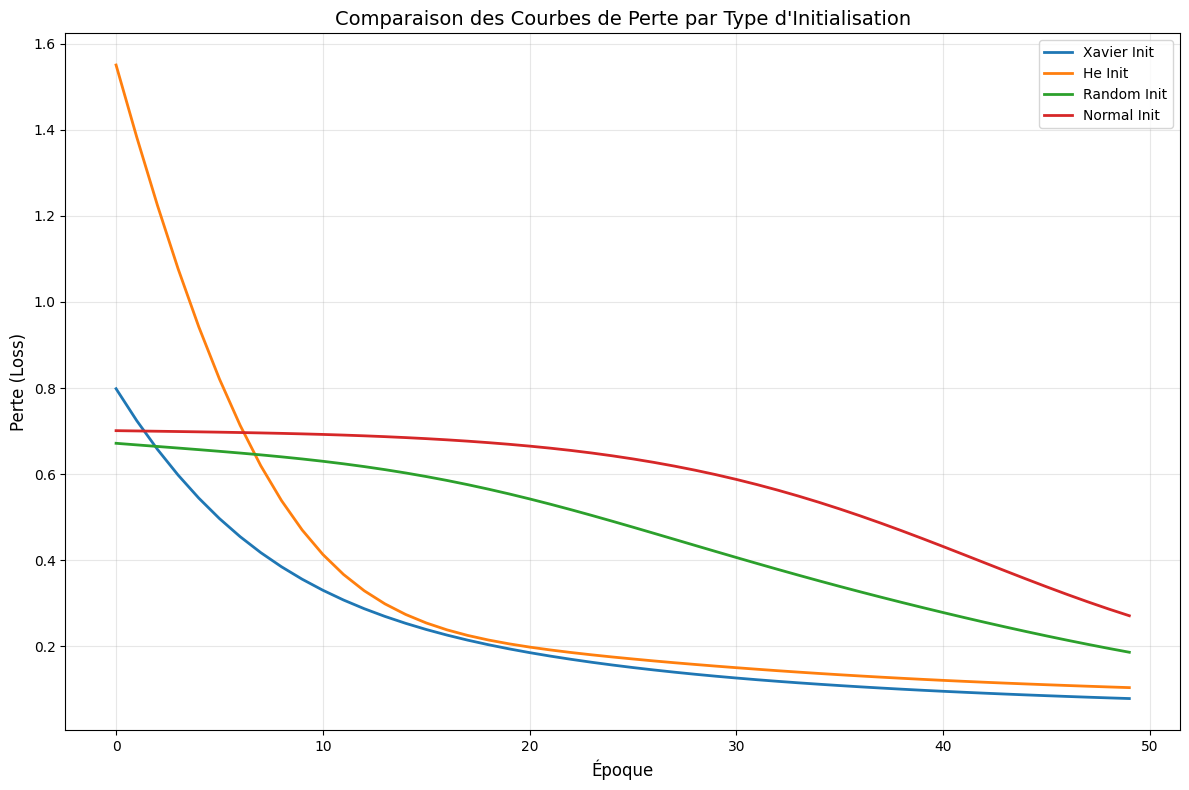

In [ ]:
# Visualisation des courbes de perte pour chaque initialisation
plt.figure(figsize=(12, 8))

for init_type in initialization_types:
    plt.plot(results[init_type]['train_losses'], label=f'{init_type.capitalize()} Init', linewidth=2)

plt.title('Comparaison des Courbes de Perte par Type d\'Initialisation', fontsize=14)
plt.xlabel('Époque', fontsize=12)
plt.ylabel('Perte (Loss)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

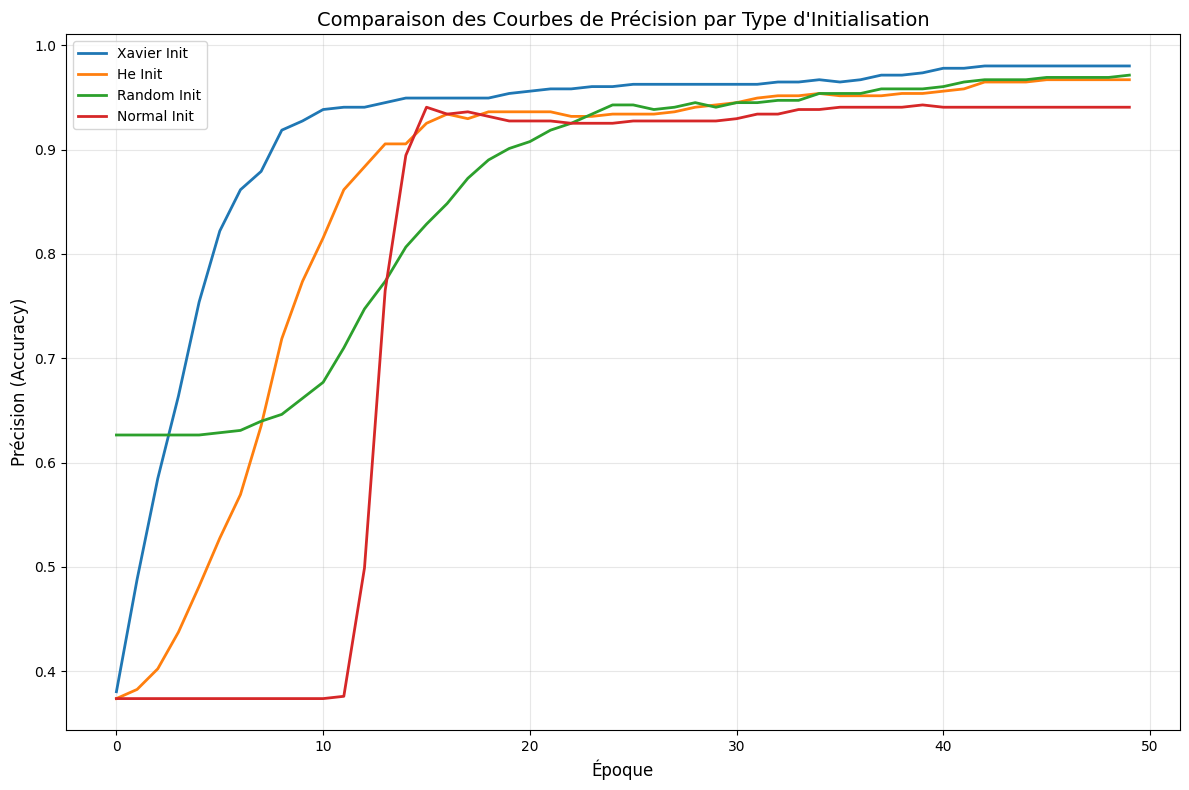

In [ ]:
# Visualisation des courbes de précision pour chaque initialisation
plt.figure(figsize=(12, 8))

for init_type in initialization_types:
    plt.plot(results[init_type]['train_accuracies'], label=f'{init_type.capitalize()} Init', linewidth=2)

plt.title('Comparaison des Courbes de Précision par Type d\'Initialisation', fontsize=14)
plt.xlabel('Époque', fontsize=12)
plt.ylabel('Précision (Accuracy)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Tableau comparatif des performances
import pandas as pd

comparison_data = []
for init_type in initialization_types:
    comparison_data.append({
        'Initialisation': init_type.capitalize(),
        'Accuracy': f"{results[init_type]['test_accuracy']:.4f}",
        'Precision': f"{results[init_type]['test_precision']:.4f}",
        'Recall': f"{results[init_type]['test_recall']:.4f}",
        'F1 Score': f"{results[init_type]['test_f1']:.4f}",
        'Loss Finale': f"{results[init_type]['train_losses'][-1]:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print("Tableau Comparatif des Performances par Type d'Initialisation:")
print("=" * 80)
print(comparison_df.to_string(index=False))

Tableau Comparatif des Performances par Type d'Initialisation:
Initialisation Accuracy Precision Recall F1 Score Loss Finale
        Xavier   0.9649    0.9857 0.9583   0.9718      0.0788
            He   0.9474    0.9459 0.9722   0.9589      0.1042
        Random   0.9386    0.9710 0.9306   0.9504      0.1864
        Normal   0.9298    0.9444 0.9444   0.9444      0.2712


In [ ]:
# Analyse des résultats
print("ANALYSE DES TECHNIQUES D'INITIALISATION")
print("=" * 50)

best_accuracy = max(results[init_type]['test_accuracy'] for init_type in initialization_types)
best_method = [init_type for init_type in initialization_types 
               if results[init_type]['test_accuracy'] == best_accuracy][0]

print(f"🏆 Meilleure méthode d'initialisation: {best_method.upper()}")
print(f"   Accuracy: {best_accuracy:.4f}")
print()

print("Observations:")
print("• Xavier (Glorot): Bon pour les fonctions d'activation sigmoïde/tanh")
print("• He (Kaiming): Optimisé pour les fonctions d'activation ReLU")
print("• Random: Initialisation simple mais peut causer des problèmes de convergence")
print("• Normal: Distribution normale avec petite variance")

print(f"\nDans notre cas avec ReLU, la méthode {best_method} donne les meilleurs résultats.")

ANALYSE DES TECHNIQUES D'INITIALISATION
🏆 Meilleure méthode d'initialisation: XAVIER
   Accuracy: 0.9649

Observations:
• Xavier (Glorot): Bon pour les fonctions d'activation sigmoïde/tanh
• He (Kaiming): Optimisé pour les fonctions d'activation ReLU
• Random: Initialisation simple mais peut causer des problèmes de convergence
• Normal: Distribution normale avec petite variance

Dans notre cas avec ReLU, la méthode xavier donne les meilleurs résultats.


In [ ]:
# Sauvegarde du meilleur modèle
best_model = create_model_with_init(best_method)
train_losses, train_accuracies = train_model(best_model, num_epochs=100)

torch.save({
    'model_state_dict': best_model.state_dict(),
    'init_method': best_method,
    'final_accuracy': results[best_method]['test_accuracy'],
    'train_losses': train_losses,
    'train_accuracies': train_accuracies
}, f'best_model_{best_method}_init.pth')

print(f"✅ Meilleur modèle sauvegardé avec: best_model_{best_method}_init.pth")

✅ Meilleur modèle sauvegardé avec: best_model_xavier_init.pth


# CONCLUSION FINALE DU PROJET

## Réalisations Accomplies
✅ **Préparation du dataset**: Dataset Breast Cancer Wisconsin avec preprocessing complet  
✅ **Construction MLP**: Architecture 30-64-32-2 avec activation ReLU  
✅ **Entraînement et évaluation**: Métriques complètes (Accuracy, Precision, Recall, F1)  
✅ **Comparaison d'initialisations**: Xavier, He, Random, Normal  
✅ **Sauvegarde et rechargement**: Modèles persistants avec métadonnées  

## Points Clés Appris
1. **Importance du preprocessing**: La normalisation est cruciale pour la convergence
2. **Impact de l'initialisation**: Different méthodes donnent des performances variables
3. **Choix de l'initialisation**: He est généralement meilleur pour ReLU
4. **Suivi des métriques**: Essential pour comprendre la performance du modèle
5. **Persistance des modèles**: Important pour la production et le déploiement

## Perspectives d'Amélioration
- Essayer différentes architectures (plus de couches, différents nombres de neurones)
- Expérimenter avec d'autres optimiseurs (SGD, RMSprop)
- Ajouter du régularisation (Dropout, L2)
- Utiliser des techniques d'early stopping
- Tester sur d'autres datasets tabulaires